In [6]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio import SeqIO
import phd_pkg

phd_pkg.viz.matplotlib_style()
phd_pkg.viz.my_color_dict


weight = 'regular'
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Lato"],

    "font.weight": weight,        # ticks, text
    "axes.labelweight": weight,   # axis labels
    "axes.titleweight": weight,   # titles
})


In [2]:
df_ex = pd.read_csv('ex_all.csv', index_col=0)
df_ex

,promoter,expression_shift,pos,base,wt_base,ind
0,TSS_1414_storz_regulondb,-29.833116,-115,1,G,1-1
1,TSS_1414_storz_regulondb,-53.180848,-115,2,G,1-1
2,TSS_1414_storz_regulondb,0.000000,-115,3,G,1-1
3,TSS_1414_storz_regulondb,-70.008817,-115,4,G,1-1
4,TSS_1414_storz_regulondb,0.000000,-114,1,A,1-1
...,...,...,...,...,...,...
635,znuCp,313.909061,43,4,C,9-2
636,znuCp,-70.813989,44,1,C,9-2
637,znuCp,0.000000,44,2,C,9-2
638,znuCp,51.212271,44,3,C,9-2


In [ ]:
# ── Notebook cell: run analysis ──────────────────────────────────
from score_denovo_motif import run_analysis, BASE_TO_IDX
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

(denovo_pwm, known_pwms, freqs, consensus, results, details,
            known_seqs, null_norms, threshold_95, threshold_99,
            denovo_self_score) = run_analysis(
    shift_df=df_ex,
    binding_sites={
        'yjbJ_predicted': (-34, -14),
        'ybaY_predicted': (-87, -67),
        #'yqjE_yqjK_yqjD_yqjC_predicted': (-72, -52),
    },
    highlight_tfs=['OmpR', 'CRP', 'Fis', 'IHF', 'H-NS', 'Lrp', 'RcsB', 'CpxR'],
    genome_path='../data/mg1655_genome.fasta',
    binding_sites_csv='binding_sites.csv',
    wt_sequences_csv='../data/wt_sequences.csv',
    tss_in_seq=115,
    condition=36,
    beta=0.001,
    min_sites=3,
    n_random=1000,
)


# ── Notebook cell: thesis figure ─────────────────────────────────

# Compute self-scores and normalized scores
wt_seqs = {p: d['wt_sequence'] for p, d in details.items()}

self_scores = {}
for tf, pwm in known_pwms.items():
    scores = []
    for seq in known_seqs[tf]:
        s = sum(pwm[i, BASE_TO_IDX.get(seq[i], 0)] for i in range(len(seq)))
        scores.append(s)
    self_scores[tf] = np.mean(scores)

results['self_score'] = results['tf'].map(self_scores)
results['norm_score'] = results['mean_site_score'] / results['self_score']

# Config
bases = ['A', 'C', 'G', 'T']
base_colors = {'A': '#7aa974', 'C': '#738fc1', 'G': '#eac264', 'T': '#d14241'}
L = freqs.shape[0]
highlight_tfs = ['OmpR', 'CRP', 'Fis', 'IHF', 'H-NS', 'Lrp', 'RcsB', 'CpxR']
top_n = 10

fig = plt.figure(figsize=(5, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.3)

# ── Panel A: Logo ──
ax_logo = fig.add_subplot(gs[0])

ic = np.zeros(L)
for i in range(L):
    entropy = -np.sum(freqs[i] * np.log2(freqs[i] + 1e-10))
    ic[i] = 2 - entropy

for i in range(L):
    order = np.argsort(freqs[i])
    y = 0
    for j in order:
        height = freqs[i, j] * ic[i]
        if height > 0.01:
            ax_logo.bar(i, height, bottom=y, width=0.8,
                        color=base_colors[bases[j]], edgecolor='none')
            if height > 0.2:
                ax_logo.text(i, y + height / 2, bases[j],
                             ha='center', va='center', fontsize=5,
                             fontweight='bold', color='white')
        y += height

ax_logo.set_xlim(-0.5, L - 0.5)
ax_logo.set_ylim(0, 2.1)
ax_logo.set_yticks([0, 0.5, 1, 1.5], [0, 0.5, 1, 1.5], fontsize=5)
ax_logo.set_ylabel('Information (bits)', fontsize=6)
ax_logo.set_title('A', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)

# WT sequences below logo
for k, (name, seq) in enumerate(wt_seqs.items()):
    y_pos = -0.3 - k * 0.22
    display = (name.replace('_predicted', '')
               .replace('_', '/').replace('yqjE/yqjK/yqjD/yqjC', 'yqjE'))
    for i, base in enumerate(seq[:L]):
        ax_logo.text(i, y_pos, base, ha='center', va='center',
                     fontsize=5, color=base_colors.get(base, 'black'))
    ax_logo.text(-1.5, y_pos, display, ha='right', va='center',
                 fontsize=6, style='italic')
bottom = -0.3 - len(wt_seqs) * 0.22 - 0.1
ax_logo.set_ylim(bottom, 2.1)
ax_logo.set_xticks(np.arange(0, 21, step=5), np.arange(0, 21, step=5), fontsize=5)
ax_logo.set_xlabel('Position in binding site', fontsize=6)

# ── Panel B: Scatter with empirical null threshold ──
ax = fig.add_subplot(gs[1])
res = results.dropna(subset=['mean_site_score', 'self_score']).copy()

# All TFs gray
ax.scatter(res['pwm_correlation'], res['norm_score'],
           c='#cccccc', s=15, alpha=0.5, edgecolors='none', zorder=1)

# Highlighted in red
hl = res[res['tf'].isin(highlight_tfs)]
ax.scatter(hl['pwm_correlation'], hl['norm_score'],
           c='#d62728', s=20, alpha=0.9, edgecolors='black',
           linewidths=0.5, zorder=3, label='Osmotic stress TFs')

# Top N in blue
top = res.sort_values('combined_rank').head(top_n)
top_not_hl = top[~top['tf'].isin(highlight_tfs)]
ax.scatter(top_not_hl['pwm_correlation'], top_not_hl['norm_score'],
           c='#1f77b4', s=30, alpha=0.8, edgecolors='black',
           linewidths=0.5, zorder=2, label=f'Top {top_n} overall')

# Empirical null threshold (99th percentile of random sequences)
ax.axhline(y=threshold_99, color='#2ca02c', linestyle='--', linewidth=1.2,
           alpha=0.7, zorder=0)
ymin = min(res['norm_score'].min() * 1.05, -1.5)
ymax = max(threshold_99 * 1.5, res['norm_score'].max() * 1.1, 0.5)
ax.set_ylim(-4, 1.5)
ax.axhspan(threshold_99, 1.5, alpha=0.06, color='#2ca02c', zorder=0)
ax.text(0.98, threshold_99 + (ymax - ymin) * 0.01,
        f'99th percentile of random sequences',
        transform=ax.get_yaxis_transform(), fontsize=5,
        color='#2ca02c', ha='right', va='bottom', style='italic')

# Labels for highlighted TFs
labeled = set()
for _, row in hl.iterrows():
    if row['tf'] not in labeled:
        labeled.add(row['tf'])
        ax.annotate(row['tf'], (row['pwm_correlation'], row['norm_score']),
                    fontsize=5, color='#d62728', fontweight='bold',
                    xytext=(5, 4), textcoords='offset points')

ax.set_xlabel('PWM correlation with de novo motif', fontsize=6)
ax.set_ylabel('Site score / self-score\n(1.0 = matches as well as true sites)',
              fontsize=6)
ax.set_title('B', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)
ax.legend(fontsize=5, loc='lower right', framealpha=0.9, edgecolor='gray')
ax.tick_params(labelsize=5)


plt.savefig('salt_motif_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()


STEP 1: Reshape expression shifts
  Condition 36: 143360 rows, reps: ['36-1', '36-2']
  yjbJ_predicted: 160 positions
  ybaY_predicted: 160 positions

STEP 2: Build de novo PWM
  yjbJ_predicted: WT=ACGGTTAAAAATTCTGAATA, 20/20 pos with data
  ybaY_predicted: WT=TGGGTGCAATGGTCTGAATT, 20/20 pos with data

  Consensus: TGTGGTAAATAATCCGAAAT
    yjbJ_predicted: ACGGTTAAAAATTCTGAATA  (11/20 match)
    ybaY_predicted: TGGGTGCAATGGTCTGAATT  (12/20 match)

STEP 3: Build known TF PWMs
  Genome: 4,641,652 bp
  PWMs for 145 TFs

STEP 4: Empirical null distribution
  Sampled 1000 random 30-mers (de novo PWM width: 20)


In [16]:
denovo_self_score / np.mean(denovo_self_score)

array([0.82435561, 1.17564439])

In [17]:
threshold_99

np.float64(-0.06961665293067947)

In [18]:
freqs

array([[1.84334511e-01, 1.11000266e-01, 3.20379765e-02, 6.72627247e-01],
       [1.17307632e-01, 3.80334638e-02, 6.07073228e-01, 2.37585676e-01],
       [1.18806269e-02, 2.30228659e-01, 1.24851646e-01, 6.33039068e-01],
       [1.70491078e-02, 7.80406711e-04, 9.75137540e-01, 7.03294547e-03],
       [6.53513269e-03, 2.69996805e-03, 4.98985568e-01, 4.91779331e-01],
       [9.32794827e-02, 6.06083897e-02, 3.77700434e-01, 4.68411694e-01],
       [6.84537852e-01, 1.06942512e-01, 1.97693710e-01, 1.08259255e-02],
       [9.49635905e-01, 4.42146442e-03, 2.09749200e-02, 2.49677101e-02],
       [8.50720680e-01, 2.87197650e-02, 5.46162697e-02, 6.59432854e-02],
       [8.34890846e-02, 8.70521273e-02, 3.81417647e-01, 4.48041141e-01],
       [5.28957156e-01, 1.07920569e-02, 6.32485895e-02, 3.97002198e-01],
       [4.12230609e-01, 8.97884128e-02, 1.66368852e-01, 3.31612126e-01],
       [9.18613276e-03, 1.66121842e-02, 4.41017582e-03, 9.69791507e-01],
       [8.60668223e-03, 9.84337304e-01, 4.16419088e

In [5]:
# ── Fixed notebook cell: run analysis ────────────────────────────
# Replace: from score_denovo_motif import run_analysis, BASE_TO_IDX
# With:
from score_denovo_motif import run_analysis, BASE_TO_IDX
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

(denovo_pwm, known_pwms, freqs, consensus, results, details,
 known_seqs, null_norms, threshold_95, threshold_99) = run_analysis(
    shift_df=df_ex,
    binding_sites={
        'ybiY_ybiW_predicted': (-5, 20),
    },
    highlight_tfs=['OmpR', 'CRP', 'Fis', 'IHF', 'H-NS', 'Lrp', 'RcsB', 'CpxR',
                   'FNR', 'ArcA', 'NarL', 'NarP'],  # added anaerobic regulators
    genome_path='../data/mg1655_genome.fasta',
    binding_sites_csv='binding_sites.csv',
    wt_sequences_csv='../data/wt_sequences.csv',
    tss_in_seq=115,
    condition=34,   # anaerobic — the condition with clear two-replicate signal
    beta=0.001,
    min_sites=3,
    n_random=1000,
)


# ── Fixed notebook cell: thesis figure ───────────────────────────

# Compute self-scores and normalized scores
wt_seqs = {p: d['wt_sequence'] for p, d in details.items()}

self_scores = {}
for tf, pwm in known_pwms.items():
    scores = []
    for seq in known_seqs[tf]:
        s = sum(pwm[i, BASE_TO_IDX.get(seq[i], 0)] for i in range(len(seq)))
        scores.append(s)
    self_scores[tf] = np.mean(scores)

results['self_score'] = results['tf'].map(self_scores)

# Safe normalization: avoid division by zero or negative self-scores
results['norm_score'] = np.where(
    (results['self_score'] > 0) & results['mean_site_score'].notna(),
    results['mean_site_score'] / results['self_score'],
    np.nan
)

# Config
bases = ['A', 'C', 'G', 'T']
base_colors = {'A': '#7aa974', 'C': '#738fc1', 'G': '#eac264', 'T': '#d14241'}
L = freqs.shape[0]
highlight_tfs = ['OmpR', 'CRP', 'Fis', 'IHF', 'H-NS', 'Lrp', 'RcsB', 'CpxR',
                 'FNR', 'ArcA', 'NarL', 'NarP']
top_n = 10

fig = plt.figure(figsize=(5, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.3)

# ── Panel A: Logo ──
ax_logo = fig.add_subplot(gs[0])

ic = np.zeros(L)
for i in range(L):
    entropy = -np.sum(freqs[i] * np.log2(freqs[i] + 1e-10))
    ic[i] = 2 - entropy

for i in range(L):
    order = np.argsort(freqs[i])
    y = 0
    for j in order:
        height = freqs[i, j] * ic[i]
        if height > 0.01:
            ax_logo.bar(i, height, bottom=y, width=0.8,
                        color=base_colors[bases[j]], edgecolor='none')
            if height > 0.2:
                ax_logo.text(i, y + height / 2, bases[j],
                             ha='center', va='center', fontsize=5,
                             fontweight='bold', color='white')
        y += height

ax_logo.set_xlim(-0.5, L - 0.5)
ax_logo.set_ylim(0, 2.1)
ax_logo.set_yticks([0, 0.5, 1, 1.5], [0, 0.5, 1, 1.5], fontsize=5)
ax_logo.set_ylabel('Information (bits)', fontsize=6)
ax_logo.set_title('A', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)

# WT sequences below logo
for k, (name, seq) in enumerate(wt_seqs.items()):
    y_pos = -0.3 - k * 0.22
    display = (name.replace('_predicted', '')
               .replace('_', '/').replace('yqjE/yqjK/yqjD/yqjC', 'yqjE'))
    for i, base in enumerate(seq[:L]):
        ax_logo.text(i, y_pos, base, ha='center', va='center',
                     fontsize=5, color=base_colors.get(base, 'black'))
    ax_logo.text(-1.5, y_pos, display, ha='right', va='center',
                 fontsize=6, style='italic')
bottom = -0.3 - len(wt_seqs) * 0.22 - 0.1
ax_logo.set_ylim(bottom, 2.1)
ax_logo.set_xticks(np.arange(0, L, step=10), np.arange(-35, -35 + L, step=10), fontsize=5)
ax_logo.set_xlabel('Position relative to predicted TSS', fontsize=6)

# ── Panel B: Scatter with empirical null threshold ──
ax = fig.add_subplot(gs[1])

# Filter to rows with finite scores
res = results.dropna(subset=['mean_site_score', 'self_score', 'norm_score']).copy()
res = res[np.isfinite(res['norm_score'])].copy()

if len(res) == 0:
    ax.text(0.5, 0.5, 'No finite scores\n(check PWM width vs site width)',
            transform=ax.transAxes, ha='center', va='center', fontsize=8)
else:
    # All TFs gray
    ax.scatter(res['pwm_correlation'], res['norm_score'],
               c='#cccccc', s=15, alpha=0.5, edgecolors='none', zorder=1)

    # Highlighted TFs in red
    hl = res[res['tf'].isin(highlight_tfs)]
    if len(hl) > 0:
        ax.scatter(hl['pwm_correlation'], hl['norm_score'],
                   c='#d62728', s=20, alpha=0.9, edgecolors='black',
                   linewidths=0.5, zorder=3, label='Anaerobic regulators')

    # Top N in blue
    top = res.sort_values('combined_rank').head(top_n)
    top_not_hl = top[~top['tf'].isin(highlight_tfs)]
    if len(top_not_hl) > 0:
        ax.scatter(top_not_hl['pwm_correlation'], top_not_hl['norm_score'],
                   c='#1f77b4', s=30, alpha=0.8, edgecolors='black',
                   linewidths=0.5, zorder=2, label=f'Top {top_n} overall')

    # Empirical null threshold (only if finite)
    if np.isfinite(threshold_99) and threshold_99 != 0:
        ax.axhline(y=threshold_99, color='#2ca02c', linestyle='--',
                   linewidth=1.2, alpha=0.7, zorder=0)
        ymin = min(res['norm_score'].min() * 1.05, -0.5)
        ymax = max(threshold_99 * 1.5, res['norm_score'].max() * 1.1, 0.5)
        ax.set_ylim(ymin, ymax)
        ax.axhspan(threshold_99, ymax, alpha=0.06, color='#2ca02c', zorder=0)
        ax.text(0.98, threshold_99 + (ymax - ymin) * 0.01,
                '99th percentile of random sequences',
                transform=ax.get_yaxis_transform(), fontsize=5,
                color='#2ca02c', ha='right', va='bottom', style='italic')

    # Labels for highlighted TFs
    labeled = set()
    for _, row in hl.iterrows() if len(hl) > 0 else []:
        if row['tf'] not in labeled:
            labeled.add(row['tf'])
            ax.annotate(row['tf'], (row['pwm_correlation'], row['norm_score']),
                        fontsize=5, color='#d62728', fontweight='bold',
                        xytext=(5, 4), textcoords='offset points')

    ax.set_xlabel('PWM correlation with de novo motif', fontsize=6)
    ax.set_ylabel('Site score / self-score\n(1.0 = matches as well as true sites)',
                  fontsize=6)
    ax.legend(fontsize=5, loc='lower right', framealpha=0.9, edgecolor='gray')

ax.set_title('B', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)
ax.tick_params(labelsize=5)


plt.savefig('ybiY_motif_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()


STEP 1: Reshape expression shifts
  Condition 34: 143360 rows, reps: ['34-1', '34-2']
  ybiY_ybiW_predicted: 160 positions

STEP 2: Build de novo PWM
  ybiY_ybiW_predicted: WT=ATTCGAAAGTATTTTAATGCTTGAA, 25/25 pos with data

  Consensus: GACATATTGTGTTAAAATTTTATGC
    ybiY_ybiW_predicted: ATTCGAAAGTATTTTAATGCTTGAA  (9/25 match)

STEP 3: Build known TF PWMs
  Genome: 4,641,652 bp
  PWMs for 145 TFs

STEP 4: Empirical null distribution
  Sampled 1000 random 35-mers (de novo PWM width: 25)
  Null norm_score: median=-1.034, 95th=0.017, 99th=0.529

STEP 5: Compare motifs

  De novo self-score: -15.508 (from 1 sites)

  TF                Corr  SiteScr  SelfScr   Norm   Rank     n
  --------------- ------ -------- -------- ------ ------ -----
  YjjQ             0.356     2.59    12.21  0.212    8.5     7
  IdnR             0.389    -1.69    20.58 -0.082   10.0     4
  ExuR             0.440    -3.70    13.78 -0.269   13.0    14
  RcsB-BglJ        0.347     0.05    16.61  0.003   14.0    12
  Pa

ValueError: too many values to unpack (expected 10, got 11)

STEP 1: Reshape expression shifts
  Condition 7: 143360 rows, reps: ['7-1', '7-2']
  yagB_insX_yagA_predicted: 160 positions

STEP 2: Build de novo PWM
  yagB_insX_yagA_predicted: WT=TTTTGTTCTACATTATAGAACAGCGTTC, 28/28 pos with data

  Consensus: TGTTAGGTTATACTTATCATGAAGCAAG
    yagB_insX_yagA_predicted: TTTTGTTCTACATTATAGAACAGCGTTC  (9/28 match)

STEP 3: Build known TF PWMs
  Genome: 4,641,652 bp
  PWMs for 145 TFs

STEP 4: Empirical null distribution
  Sampled 1000 random 38-mers (de novo PWM width: 28)
  Null norm_score: median=-1.750, 95th=-0.589, 99th=-0.240

STEP 5: Compare motifs

  TF                Corr  MeanScore   Rank     n
  --------------- ------ ---------- ------ -----
  IdnR             0.418      -4.91    2.0     4
  GntR             0.381      -9.65    5.5    17
  CaiF             0.355      -8.08    6.5     8
  RelBE            0.354      -8.42    7.5     4
  DpiA             0.364      -9.97    8.0     9
  PdhR             0.400     -11.60   10.0    19
  LldR       

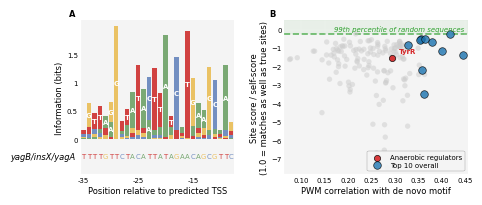

In [ ]:
# ── Fixed notebook cell: run analysis ────────────────────────────
# Replace: from score_denovo_motif import run_analysis, BASE_TO_IDX
# With:
from score_denovo_motif import run_analysis, BASE_TO_IDX
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

(denovo_pwm, known_pwms, freqs, consensus, results, details,
 known_seqs, null_norms, threshold_95, threshold_99) = run_analysis(
    shift_df=df_ex,
    binding_sites={
        'yagB_insX_yagA_predicted': (-53, -25),
    },
    highlight_tfs=['TyrR'],  # added anaerobic regulators
    genome_path='../data/mg1655_genome.fasta',
    binding_sites_csv='binding_sites.csv',
    wt_sequences_csv='../data/wt_sequences.csv',
    tss_in_seq=115,
    condition=7,   # anaerobic — the condition with clear two-replicate signal
    beta=0.01,
    min_sites=3,
    n_random=1000,
)


# ── Fixed notebook cell: thesis figure ───────────────────────────

# Compute self-scores and normalized scores
wt_seqs = {p: d['wt_sequence'] for p, d in details.items()}

self_scores = {}
for tf, pwm in known_pwms.items():
    scores = []
    for seq in known_seqs[tf]:
        s = sum(pwm[i, BASE_TO_IDX.get(seq[i], 0)] for i in range(len(seq)))
        scores.append(s)
    self_scores[tf] = np.mean(scores)

results['self_score'] = results['tf'].map(self_scores)

# Safe normalization: avoid division by zero or negative self-scores
results['norm_score'] = np.where(
    (results['self_score'] > 0) & results['mean_site_score'].notna(),
    results['mean_site_score'] / results['self_score'],
    np.nan
)

# Config
bases = ['A', 'C', 'G', 'T']
base_colors = {'A': '#7aa974', 'C': '#738fc1', 'G': '#eac264', 'T': '#d14241'}
L = freqs.shape[0]
highlight_tfs = ['TyrR']#, 'CRP', 'Fis', 'IHF', 'H-NS', 'Lrp', 'RcsB', 'CpxR',
#                  'FNR', 'ArcA', 'NarL', 'NarP']
top_n = 10

fig = plt.figure(figsize=(5, 2))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.3)

# ── Panel A: Logo ──
ax_logo = fig.add_subplot(gs[0])

ic = np.zeros(L)
for i in range(L):
    entropy = -np.sum(freqs[i] * np.log2(freqs[i] + 1e-10))
    ic[i] = 2 - entropy

for i in range(L):
    order = np.argsort(freqs[i])
    y = 0
    for j in order:
        height = freqs[i, j] * ic[i]
        if height > 0.01:
            ax_logo.bar(i, height, bottom=y, width=0.8,
                        color=base_colors[bases[j]], edgecolor='none')
            if height > 0.2:
                ax_logo.text(i, y + height / 2, bases[j],
                             ha='center', va='center', fontsize=5,
                             fontweight='bold', color='white')
        y += height

ax_logo.set_xlim(-0.5, L - 0.5)
ax_logo.set_ylim(0, 2.1)
ax_logo.set_yticks([0, 0.5, 1, 1.5], [0, 0.5, 1, 1.5], fontsize=5)
ax_logo.set_ylabel('Information (bits)', fontsize=6)
ax_logo.set_title('A', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)

# WT sequences below logo
for k, (name, seq) in enumerate(wt_seqs.items()):
    y_pos = -0.3 - k * 0.22
    display = (name.replace('_predicted', '')
               .replace('_', '/').replace('yqjE/yqjK/yqjD/yqjC', 'yqjE'))
    for i, base in enumerate(seq[:L]):
        ax_logo.text(i, y_pos, base, ha='center', va='center',
                     fontsize=5, color=base_colors.get(base, 'black'))
    ax_logo.text(-1.5, y_pos, display, ha='right', va='center',
                 fontsize=6, style='italic')
bottom = -0.3 - len(wt_seqs) * 0.22 - 0.1
ax_logo.set_ylim(bottom, 2.1)
ax_logo.set_xticks(np.arange(0, L, step=10), np.arange(-35, -35 + L, step=10), fontsize=5)
ax_logo.set_xlabel('Position relative to predicted TSS', fontsize=6)

# ── Panel B: Scatter with empirical null threshold ──
ax = fig.add_subplot(gs[1])

# Filter to rows with finite scores
res = results.dropna(subset=['mean_site_score', 'self_score', 'norm_score']).copy()
res = res[np.isfinite(res['norm_score'])].copy()

if len(res) == 0:
    ax.text(0.5, 0.5, 'No finite scores\n(check PWM width vs site width)',
            transform=ax.transAxes, ha='center', va='center', fontsize=8)
else:
    # All TFs gray
    ax.scatter(res['pwm_correlation'], res['norm_score'],
               c='#cccccc', s=15, alpha=0.5, edgecolors='none', zorder=1)

    # Highlighted TFs in red
    hl = res[res['tf'].isin(highlight_tfs)]
    if len(hl) > 0:
        ax.scatter(hl['pwm_correlation'], hl['norm_score'],
                   c='#d62728', s=20, alpha=0.9, edgecolors='black',
                   linewidths=0.5, zorder=3, label='Anaerobic regulators')

    # Top N in blue
    top = res.sort_values('combined_rank').head(top_n)
    top_not_hl = top[~top['tf'].isin(highlight_tfs)]
    if len(top_not_hl) > 0:
        ax.scatter(top_not_hl['pwm_correlation'], top_not_hl['norm_score'],
                   c='#1f77b4', s=30, alpha=0.8, edgecolors='black',
                   linewidths=0.5, zorder=2, label=f'Top {top_n} overall')

    # Empirical null threshold (only if finite)
    if np.isfinite(threshold_99) and threshold_99 != 0:
        ax.axhline(y=threshold_99, color='#2ca02c', linestyle='--',
                   linewidth=1.2, alpha=0.7, zorder=0)
        ymin = min(res['norm_score'].min() * 1.05, -0.5)
        ymax = max(threshold_99 * 1.5, res['norm_score'].max() * 1.1, 0.5)
        ax.set_ylim(ymin, ymax)
        ax.axhspan(threshold_99, ymax, alpha=0.06, color='#2ca02c', zorder=0)
        ax.text(0.98, threshold_99 + (ymax - ymin) * 0.01,
                '99th percentile of random sequences',
                transform=ax.get_yaxis_transform(), fontsize=5,
                color='#2ca02c', ha='right', va='bottom', style='italic')

    # Labels for highlighted TFs
    labeled = set()
    for _, row in hl.iterrows() if len(hl) > 0 else []:
        if row['tf'] not in labeled:
            labeled.add(row['tf'])
            ax.annotate(row['tf'], (row['pwm_correlation'], row['norm_score']),
                        fontsize=5, color='#d62728', fontweight='bold',
                        xytext=(5, 4), textcoords='offset points')

    ax.set_xlabel('PWM correlation with de novo motif', fontsize=6)
    ax.set_ylabel('Site score / self-score\n(1.0 = matches as well as true sites)',
                  fontsize=6)
    ax.legend(fontsize=5, loc='lower right', framealpha=0.9, edgecolor='gray')

ax.set_title('B', fontsize=6, fontweight='bold', loc='left', x=-0.08, y=1.0)
ax.tick_params(labelsize=5)

plt.savefig('yagB_motif_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
results.sort_values(by='norm_score')

,tf,pwm_correlation,mean_site_score,n_sites,corr_rank,score_rank,combined_rank,self_score,norm_score
4,NarL,0.069169,-35.320118,121,112.0,108.0,110.0,2.501373,-14.120293
137,MetJ,0.266409,-30.279267,33,25.0,73.0,49.0,2.439342,-12.412885
6,Lrp,0.202142,-29.210848,219,50.0,66.0,58.0,2.376103,-12.293593
126,SoxS,0.215747,-32.479651,44,39.0,91.0,65.0,2.664112,-12.191549
52,GlaR,0.176857,-33.326091,116,66.0,96.0,81.0,3.424839,-9.730703
...,...,...,...,...,...,...,...,...,...
38,MngR,0.302268,-15.481738,4,17.0,8.0,12.5,16.999375,-0.910724
78,RcsAB,0.420339,-11.499934,6,2.0,2.0,2.0,13.700784,-0.839363
87,IlvY,0.292061,-12.312094,6,21.0,4.0,12.5,14.960906,-0.822951
122,LrhA,0.370150,-14.878858,4,6.0,6.0,6.0,19.672223,-0.756338


In [ ]:
print(results.head(20))

            tf  pwm_correlation  mean_site_score  n_sites  corr_rank  \
78       RcsAB         0.420339       -11.499934        6        2.0   
28        RcsB         0.523693       -12.186986       12        1.0   
118       AllR         0.370524        -4.995158        3        5.0   
122       LrhA         0.370150       -14.878858        4        6.0   
55        NhaR         0.354227       -15.117893        7        8.0   
121        CRP         0.388500       -21.247787      438        3.0   
50        GadE         0.316833       -16.721462       15       12.0   
87        IlvY         0.292061       -12.312094        6       21.0   
38        MngR         0.302268       -15.481738        4       17.0   
14        AraC         0.348008       -22.830268       27        9.0   
49        ArgP         0.360885       -23.729561       19        7.0   
60         Fur         0.374726       -24.361885      217        4.0   
62   RcsB-BglJ         0.313951       -22.186022       12       

Genome: 4,641,652 bp
Gene positions: 4726 genes


/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_46356/3226595280.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ).reset_index(names='locus_tag')


Fold changes computed for 4257 genes
  Top 5: gene_name  salt_log2fc
      bdm     8.228432
     yciF     7.219565
     proX     6.521899
     proW     6.392930
     yciE     6.389830
Scored 4726 promoters
  Mean score: -1.72, Median: -2.16, MAD: 3.05

Known site scores for reference:
  yjbJ: score=6.88, z=1.88, rz=2.00
  ybaY: score=9.81, z=2.52, rz=2.65

Salt-upregulated genes (log2fc > 1.5) ranked by motif score
Gene           Score      z     rz  log2fc  SaltRank Sequence
------------ ------- ------ ------ ------- --------- --------------------
sufB           14.22   3.48   3.62    2.56       153 ATTCAGGAACCTTTAACCCA
motB           13.89   3.41   3.55    1.70       318 TGCGGTGAAAAATCCGCAAC
yghX           12.13   3.02   3.16    2.17       214 CGCGTTAACGTGACCGAAAT
sra            11.51   2.89   3.02    3.35        64 TGGGTTGAAGCTTCTGATAA
wcaE           11.36   2.85   2.99    2.58       147 CATTCGGAATATTTAACGGT
mntH           10.42   2.65   2.78    2.44       167 CTATCAGAGAAATCACCACA
t

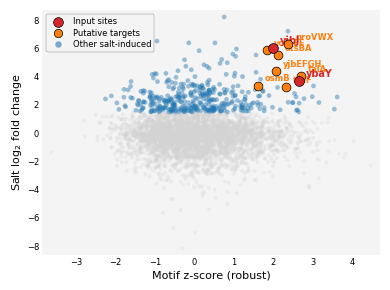

In [ ]:
"""
Score upstream promoter regions of salt-upregulated genes with the
de novo PWM. Paste into notebook after running run_analysis().

Assumes in namespace: denovo_pwm, details (from run_analysis)
Assumes files at ../data/:
    - mg1655_genome.fasta
    - gene_positions.csv  (columns: gene, left_position, right_position, strand)
    - SBRG-precise1k-71e1157/data/precise1k/log_tpm_qc.csv
    - SBRG-precise1k-71e1157/data/annotation/gene_info.csv
"""

# ── Cell 1: Load data ─────────────────────────────────────────────

import numpy as np
import pandas as pd


BASE_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
COMP = str.maketrans("ACGTacgt", "TGCAtgca")

def revcomp(seq):
    return seq.translate(COMP)[::-1]

def score_seq(seq, pwm):
    return sum(pwm[i, BASE_TO_IDX.get(seq[i], 0)] for i in range(len(seq)))

def best_score_in_region(seq, pwm):
    """Slide PWM across seq on both strands, return best score and position."""
    L = pwm.shape[0]
    if len(seq) < L:
        return -np.inf, -1, '+'
    best, best_pos, best_strand = -np.inf, -1, '+'
    rc = revcomp(seq)
    for start in range(len(seq) - L + 1):
        s_fwd = score_seq(seq[start:start + L], pwm)
        s_rev = score_seq(rc[start:start + L], pwm)
        if s_fwd > best:
            best, best_pos, best_strand = s_fwd, start, '+'
        if s_rev > best:
            best, best_pos, best_strand = s_rev, len(seq) - start - L, '-'
    return best, best_pos, best_strand

# Load genome
record = SeqIO.read('../data/mg1655_genome.fasta', 'fasta')
genome = str(record.seq).upper()
print(f"Genome: {len(genome):,} bp")

# Load gene positions
df_genes = pd.read_csv('../data/gene_positions.csv')
print(f"Gene positions: {len(df_genes)} genes")

# Load PRECISE-1K and compute salt fold changes
df_tpm = pd.read_csv(
    '../data/log_tpm_qc.csv',
    index_col=0
).reset_index(names='locus_tag')
df_gene_info = pd.read_csv(
    '../data/gene_info.csv',
    index_col=0
).reset_index()[['locus_tag', 'gene_name', 'COG']]

# Salt samples and controls — adjust sample IDs if needed
salt_runs = ['p1k_00064', 'p1k_00065', 'p1k_00066', 'p1k_00067']
control_runs = ['p1k_00001', 'p1k_00002']

df_fc = pd.DataFrame()
i = 0
for run in salt_runs:
    for ctrl in control_runs:
        df_fc[f'm{i}'] = df_tpm[run] - df_tpm[ctrl]
        i += 1
df_fc['locus_tag'] = df_tpm['locus_tag']
cols = [f'm{j}' for j in range(i)]
df_fc['salt_log2fc'] = df_fc[cols].mean(axis=1)
df_fc = pd.merge(df_gene_info, df_fc[['locus_tag', 'salt_log2fc']],
                  on='locus_tag')
print(f"Fold changes computed for {len(df_fc)} genes")
print(f"  Top 5: {df_fc.nlargest(5, 'salt_log2fc')[['gene_name','salt_log2fc']].to_string(index=False)}")


# ── Cell 2: Extract promoter regions and score ────────────────────

UPSTREAM_BP = 400  # bp upstream of CDS start to scan

def extract_upstream(gene_row, genome, upstream_bp):
    """Extract upstream_bp bases upstream of CDS start, oriented 5'->3'."""
    strand = gene_row['strand']
    if strand == 'forward':
        left = int(gene_row['left_position'])
        s = max(0, left - upstream_bp - 1)
        e = left - 1
        return genome[s:e]
    else:
        right = int(gene_row['right_position'])
        s = right  # 0-based, right_position is 1-based inclusive
        e = min(len(genome), right + upstream_bp)
        return revcomp(genome[s:e])

# Score every gene's promoter region
rows = []
for _, gene in df_genes.iterrows():
    promoter = extract_upstream(gene, genome, UPSTREAM_BP)
    if len(promoter) < denovo_pwm.shape[0]:
        continue
    score, pos, strand = best_score_in_region(promoter, denovo_pwm)
    # Extract the best-matching sequence
    L = denovo_pwm.shape[0]
    if strand == '+':
        match_seq = promoter[pos:pos + L] if pos >= 0 else ''
    else:
        match_seq = revcomp(promoter)[pos:pos + L] if pos >= 0 else ''
        # Actually just grab from the promoter at the position
        match_seq = promoter[pos:pos + L]

    rows.append({
        'gene': gene['gene'],
        'motif_score': score,
        'match_position': pos,  # bp from CDS start
        'match_strand': strand,
        'match_seq': promoter[pos:pos + L] if pos >= 0 else '',
    })

df_scores = pd.DataFrame(rows)
print(f"Scored {len(df_scores)} promoters")

# Compute z-scores
mu = df_scores['motif_score'].mean()
sd = df_scores['motif_score'].std()
df_scores['motif_zscore'] = (df_scores['motif_score'] - mu) / sd

# Robust z-score (MAD-based)
med = df_scores['motif_score'].median()
mad = np.median(np.abs(df_scores['motif_score'] - med))
df_scores['motif_rzscore'] = 0.6745 * (df_scores['motif_score'] - med) / mad

print(f"  Mean score: {mu:.2f}, Median: {med:.2f}, MAD: {mad:.2f}")


# ── Cell 3: Merge with salt fold changes ──────────────────────────

df_merged = pd.merge(
    df_scores, df_fc[['gene_name', 'salt_log2fc']],
    left_on='gene', right_on='gene_name', how='left'
).drop(columns='gene_name')

# Rank by salt fold change
df_merged['salt_rank'] = df_merged['salt_log2fc'].rank(ascending=False)

# Known sites for reference
wt_seqs = {p: d['wt_sequence'] for p, d in details.items()}
print("\nKnown site scores for reference:")
for name, seq in wt_seqs.items():
    s = score_seq(seq, denovo_pwm)
    z = (s - mu) / sd
    rz = 0.6745 * (s - med) / mad
    display_name = name.replace('_predicted', '')
    print(f"  {display_name}: score={s:.2f}, z={z:.2f}, rz={rz:.2f}")


# ── Cell 4: Show results ─────────────────────────────────────────

# Top salt-upregulated genes with motif scores
salt_threshold = 1.5  # log2 fold change
df_salt_genes = df_merged[df_merged['salt_log2fc'] > salt_threshold].copy()
df_salt_genes = df_salt_genes.sort_values('motif_score', ascending=False)

print(f"\n{'='*70}")
print(f"Salt-upregulated genes (log2fc > {salt_threshold}) ranked by motif score")
print(f"{'='*70}")
print(f"{'Gene':<12} {'Score':>7} {'z':>6} {'rz':>6} {'log2fc':>7} {'SaltRank':>9} {'Sequence'}")
print(f"{'-'*12} {'-'*7} {'-'*6} {'-'*6} {'-'*7} {'-'*9} {'-'*20}")
for _, row in df_salt_genes.head(40).iterrows():
    print(f"{row['gene']:<12} {row['motif_score']:>7.2f} "
          f"{row['motif_zscore']:>6.2f} {row['motif_rzscore']:>6.2f} "
          f"{row['salt_log2fc']:>7.2f} {int(row['salt_rank']):>9} "
          f"{row['match_seq']}")
    

print(f"\n{'='*70}")
print(f"Salt-upregulated genes (log2fc > {salt_threshold}) ranked by fold change")
print(f"{'='*70}")
print(f"{'Gene':<12} {'Score':>7} {'z':>6} {'rz':>6} {'log2fc':>7} {'SaltRank':>9} {'Sequence'}")
print(f"{'-'*12} {'-'*7} {'-'*6} {'-'*6} {'-'*7} {'-'*9} {'-'*20}")
for _, row in df_salt_genes.sort_values(by='salt_log2fc', ascending=False).head(40).iterrows():
    print(f"{row['gene']:<12} {row['motif_score']:>7.2f} "
          f"{row['motif_zscore']:>6.2f} {row['motif_rzscore']:>6.2f} "
          f"{row['salt_log2fc']:>7.2f} {int(row['salt_rank']):>9} "
          f"{row['match_seq']}")



# ── Cell 5: Thesis figure — scatter with highlighted regulon ──────

import matplotlib.pyplot as plt

# Define gene groups
input_sites = ['yjbJ', 'ybaY']
putative_regulon = ['proV', 'otsB', 'treF', 'yjbE', 'yciG', 'talA', 'osmB']
# Operons to label with arrow or note
operon_notes = {
    'proV': 'proVWX',
    'otsB': 'otsBA',
    'yciG': 'yciGFE',
    'yjbE': 'yjbEFGH',
}

fig, ax = plt.subplots(figsize=(4, 3))

# All genes — gray
ax.scatter(df_merged['motif_rzscore'], df_merged['salt_log2fc'],
           c='lightgray', s=8, alpha=0.3, edgecolors='none', zorder=1)

# Salt-upregulated but not in regulon — blue
salt_mask = (df_merged['salt_log2fc'] > salt_threshold)
regulon_mask = df_merged['gene'].isin(input_sites + putative_regulon)
other_salt = salt_mask & ~regulon_mask
ax.scatter(df_merged.loc[other_salt, 'motif_rzscore'],
           df_merged.loc[other_salt, 'salt_log2fc'],
           c='#1f77b4', s=12, alpha=0.4, edgecolors='none', zorder=2,
           label='Salt-upregulated')

# Putative regulon — orange
for gene in putative_regulon:
    row = df_merged[df_merged['gene'] == gene]
    if len(row) > 0:
        row = row.iloc[0]
        ax.scatter(row['motif_rzscore'], row['salt_log2fc'],
                   c='#ff7f0e', s=40, edgecolors='black', linewidths=0.5,
                   zorder=4)
        label = operon_notes.get(gene, gene)
        ax.annotate(label, (row['motif_rzscore'], row['salt_log2fc']),
                    fontsize=6, color='#ff7f0e', fontweight='bold',
                    xytext=(5, 3), textcoords='offset points')

# Input sites — red
for gene in input_sites:
    row = df_merged[df_merged['gene'] == gene]
    if len(row) > 0:
        row = row.iloc[0]
        ax.scatter(row['motif_rzscore'], row['salt_log2fc'],
                   c='#d62728', s=50, edgecolors='black', linewidths=0.5,
                   zorder=5)
        ax.annotate(gene, (row['motif_rzscore'], row['salt_log2fc']),
                    fontsize=7, color='#d62728', fontweight='bold',
                    xytext=(5, 3), textcoords='offset points')

# Dummy handles for legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markeredgecolor='black', markersize=7, label='Input sites'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e',
           markeredgecolor='black', markersize=6, label='Putative targets'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4',
           markersize=5, alpha=0.6, label='Other salt-induced'),
]
ax.legend(handles=handles, fontsize=6, loc='upper left', framealpha=0.9)

ax.set_xlabel('Motif z-score (robust)', fontsize=8)
ax.set_ylabel('Salt log$_2$ fold change', fontsize=8)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('salt_regulon_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Score yadI binding site against CRP PWM ──────────────────────
from score_denovo_motif import (load_genome, build_known_pwms, 
                                 extract_site, reverse_complement,
                                 BASE_TO_IDX, get_wt_sequence)
import numpy as np

# Build CRP PWM from RegulonDB sites
genome = load_genome('../data/mg1655_genome.fasta')
known_pwms, known_seqs = build_known_pwms(
    'binding_sites.csv', genome,
    site_width=20, min_sites=1, filter_evidence=['S', 'C']  # CRP has 445 sites, no issue
)

crp_pwm = known_pwms['CRP']
crp_sites = known_seqs['CRP']
crp_scores = np.array([sum(crp_pwm[i, BASE_TO_IDX[s[i]]] 
                           for i in range(20)) for s in crp_sites])

# yadI binding site — extract from your footprint
# Adjust the position range to match the activator peak you see
wt_seq = get_wt_sequence('yadI_predicted', '../data/wt_sequences.csv')
tss_in_seq = 115  # your TSS position

# Try a range of positions around where the CRP site should be
# Class II: centered at -41.5, so roughly -51 to -31
# Class I: centered at -61.5, so roughly -71 to -51
for label, (start, end) in [('identified site (-45, -20)', (-45, -20)),]:
    site = wt_seq[tss_in_seq + start : tss_in_seq + end]
    
    # Score against CRP PWM (best offset, both strands)
    best_score = -np.inf
    best_subseq = ''
    L = crp_pwm.shape[0]
    for seq in [site, reverse_complement(site)]:
        for k in range(len(seq) - L + 1):
            sub = seq[k:k+L]
            s = sum(crp_pwm[i, BASE_TO_IDX.get(sub[i], 0)] for i in range(L))
            if s > best_score:
                best_score = s
                best_subseq = sub

    pct = np.mean(crp_scores <= best_score) * 100
    print(f"{label}: score={best_score:.2f}, "
          f"percentile={pct:.1f}% among {len(crp_scores)} known CRP sites")
    print(f"  Best matching sequence: {best_subseq}")

# Also print CRP score distribution for reference
print(f"\nCRP known site scores: median={np.median(crp_scores):.2f}, "
      f"mean={np.mean(crp_scores):.2f}, "
      f"min={np.min(crp_scores):.2f}, max={np.max(crp_scores):.2f}")

identified site (-45, -20): score=8.69, percentile=35.7% among 269 known CRP sites
  Best matching sequence: GTTTTGACGGCTATCACCCT

CRP known site scores: median=10.38, mean=8.39, min=-17.63, max=19.06


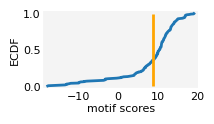

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2,1))
ax.plot(np.sort(crp_scores), np.arange(1, len(crp_scores)+1)/len(crp_scores), linewidth=2)
ax.vlines([best_score], ymin=0, ymax=1, linewidth=2, color='orange')
ax.set_xlabel("motif scores")
ax.set_ylabel("ECDF")
fig.savefig("yadI_CRP_score.pdf")

In [ ]:
best_score

np.float64(8.692353754011972)